In [43]:
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from keras.optimizers import SGD
import matplotlib.pyplot as plt

In [44]:
# -------------------------------
# 1. Load and preprocess the data
# -------------------------------
df = pd.read_csv('IBM.csv', parse_dates=['Date'], nrows=5000)
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)

# Compute features
df['Return'] = df['Close'].pct_change()
df['LogReturn'] = np.log(df['Close']) - np.log(df['Close'].shift(1))
df['Volatility'] = (df['High'] - df['Low']) / df['Open']
df['PriceChange'] = (df['Close'] - df['Open']) / df['Open']
df['VolumeChange'] = df['Volume'].pct_change()

# Handle NaN or Inf
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [45]:
# -------------------------
# 2. Fit the Hidden Markov Model
# -------------------------
hmm_features = df[['LogReturn', 'Volatility', 'VolumeChange']].values

# Ensure hmm_features is clean
valid_idx = ~np.isnan(hmm_features).any(axis=1) & ~np.isinf(hmm_features).any(axis=1)
df = df[valid_idx]
hmm_features = hmm_features[valid_idx]

# Fit HMM
n_hidden_states = 5
hmm_model = GaussianHMM(n_components=n_hidden_states, covariance_type='diag', n_iter=1000)
hmm_model.fit(hmm_features)

# Get hidden states and state means
hidden_states = hmm_model.predict(hmm_features)
state_means = hmm_model.means_

# Append HMM-derived features
df['HMM_State'] = hidden_states
df['State_Mean_LogReturn'] = state_means[hidden_states, 0]
df['State_Mean_Volatility'] = state_means[hidden_states, 1]
df['State_Mean_VolumeChange'] = state_means[hidden_states, 2]


In [46]:
# ---------------------------------
# 3. Prepare the data for LSTM
# ---------------------------------
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
               'LogReturn', 'Volatility', 'PriceChange', 'VolumeChange',
               'HMM_State', 'State_Mean_LogReturn', 'State_Mean_Volatility', 'State_Mean_VolumeChange']
target_col = 'Close'
n_lags = 45

# Scale data - only scale features, not target
scaler_features = MinMaxScaler()
scaled_features = scaler_features.fit_transform(df[feature_cols])

scaler_target = MinMaxScaler()
scaled_target = scaler_target.fit_transform(df[[target_col]])

# Combine scaled features and target
scaled_data = np.hstack([scaled_features, scaled_target])

# Create sequences
def create_sequences(data, features, target, n_lags):
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(features[i-n_lags:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, scaled_features, scaled_target, n_lags)

# Split data
split_idx = int(0.98 * len(X))
print(len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
test_open = df['Open'][split_idx:]




4952


In [47]:
# -------------------------
# 4. Build and train LSTM
# -------------------------
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(n_lags, len(feature_cols))),
    LSTM(50),
    Dense(50, activation='tanh'),
    Dense(1)
])
model.compile(optimizer='Adam', loss='mean_squared_error')
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# -------------------------
# 5. Predict and inverse transform
# -------------------------
# Predict scaled values
predicted_scaled = model.predict(X_test)

# Inverse transform predictions
predicted_close = scaler_target.inverse_transform(predicted_scaled)

# Inverse transform actual values
actual_close = scaler_target.inverse_transform(y_test.reshape(-1, 1))

mape = np.mean(np.abs((actual_close - predicted_close)/actual_close))
direction_true = np.diff(actual_close.flatten()) > 0
direction_pred = np.diff(predicted_close.flatten()) > 0
dpa = np.mean(direction_true == direction_pred) * 100
print(f"MAPE : {mape}")
print(f"DPA : {dpa}")

Epoch 1/50


/home/sunny/CS240-AIML-Labs/project/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


137/137 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0108 - val_loss: 6.9219e-04
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 5.5147e-04 - val_loss: 5.4232e-04
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 4.2188e-04 - val_loss: 4.0961e-04
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 3.2985e-04 - val_loss: 4.6790e-04
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 3.1693e-04 - val_loss: 2.7396e-04
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 2.0196e-04 - val_loss: 3.2479e-04
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 2.2255e-04 - val_loss: 2.9993e-04
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 2.1970e-04 - val_loss: 1.9491e-04
Epoch 9/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 1.6406e-04 - val_loss: 1.9733e-04
Epoch 10/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1.5381e-04 - val_loss: 3.3258e-04
Epoch 11/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1.

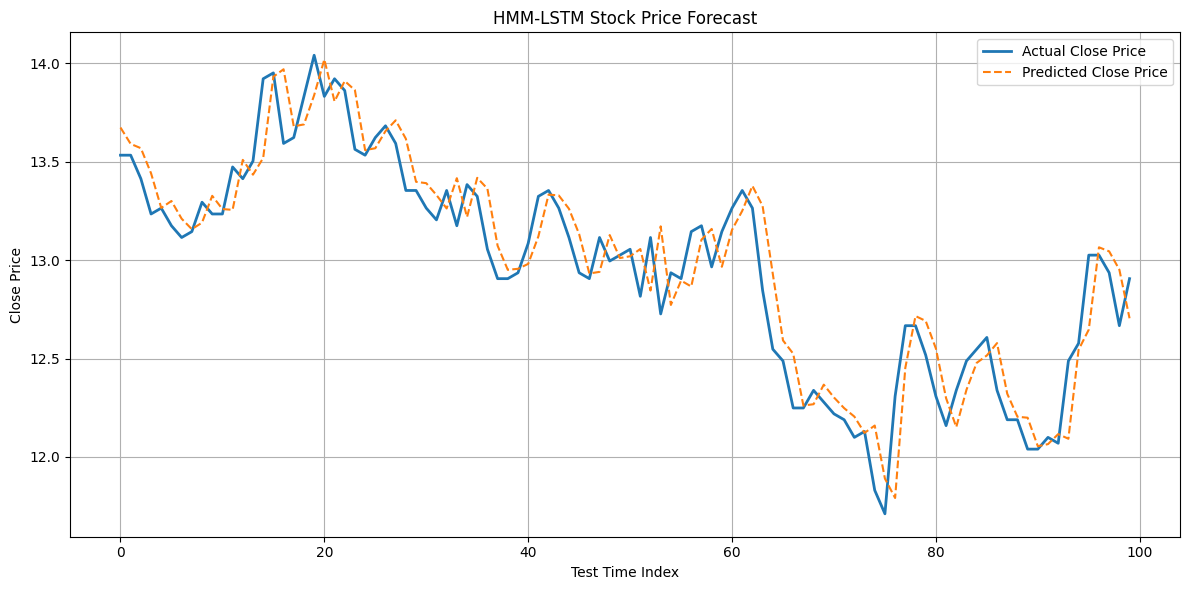

In [48]:
# -------------------------
# 6. Plot the results
# -------------------------
plt.figure(figsize=(12, 6))
plt.plot(actual_close, label='Actual Close Price', linewidth=2)
plt.plot(predicted_close, label='Predicted Close Price', linestyle='--')
plt.legend()
plt.title('HMM-LSTM Stock Price Forecast')
plt.xlabel('Test Time Index')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()